# Análisis Profesional del Dataset de Viviendas de California

Este notebook presenta un análisis detallado y profesional del clásico dataset de viviendas de California, siguiendo las mejores prácticas de análisis de datos. Cada sección aborda de manera sistemática los pasos fundamentales para la comprensión, limpieza, exploración y preparación de los datos para modelado.

---

## Índice
1. [Importar bibliotecas necesarias](#importar-bibliotecas-necesarias)
2. [Carga y exploración inicial de datos](#carga-y-exploracion-inicial-de-datos)
3. [Limpieza y preprocesamiento de datos](#limpieza-y-preprocesamiento-de-datos)
4. [Análisis exploratorio de datos (EDA)](#analisis-exploratorio-de-datos-eda)
5. [Visualización de datos](#visualizacion-de-datos)
6. [Transformación y creación de nuevas variables](#transformacion-y-creacion-de-nuevas-variables)
7. [Análisis estadístico descriptivo](#analisis-estadistico-descriptivo)
8. [Detección y tratamiento de valores atípicos](#deteccion-y-tratamiento-de-valores-atipicos)
9. [Preparación de datos para modelado](#preparacion-de-datos-para-modelado)
10. [Exportación de datos procesados](#exportacion-de-datos-procesados)

---

## 1. Importar bibliotecas necesarias

En esta sección se importan todas las bibliotecas requeridas para el análisis de datos, visualización y procesamiento. Se incluyen comentarios sobre la utilidad de cada una.

In [1]:
# Importación de bibliotecas principales para análisis de datos
import pandas as pd  # Manipulación y análisis de datos
import numpy as np  # Operaciones numéricas y algebraicas
import matplotlib.pyplot as plt  # Visualización básica
import seaborn as sns  # Visualización avanzada y análisis exploratorio
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit  # División de datos
from sklearn.impute import SimpleImputer  # Imputación de valores faltantes
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler  # Codificación y escalado
import warnings
warnings.filterwarnings('ignore')  # Para evitar mensajes de advertencia innecesarios

## 2. Carga y exploración inicial de datos

En esta sección se carga el dataset desde la fuente original y se realiza una primera inspección para entender su estructura, dimensiones y tipos de variables.

In [2]:
# Cargar el dataset desde la fuente original
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)

# Mostrar las primeras filas del dataset
print("Primeras filas del dataset:")
display(df.head())

# Dimensiones del dataset
print(f"\nDimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")

# Tipos de datos de cada columna
print("\nTipos de datos:")
display(df.dtypes)

# Nombres de las columnas
print("\nNombres de las columnas:")
print(df.columns.tolist())

Primeras filas del dataset:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Dimensiones del dataset: 20640 filas, 10 columnas

Tipos de datos:


longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


Nombres de las columnas:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


## 3. Limpieza y preprocesamiento de datos

En esta sección se identifican y tratan valores nulos, duplicados y posibles errores en los datos. Se estandarizan formatos y se corrigen inconsistencias para asegurar la calidad del dataset.

In [3]:
# Revisión de valores nulos y duplicados
print("Valores nulos por columna:")
display(df.isnull().sum())

print("\nValores NA por columna (equivalente):")
display(df.isna().sum())

print("\nFilas duplicadas:")
print(df.duplicated().sum())

# Eliminación de duplicados si existen
df = df.drop_duplicates()

# Análisis de valores nulos en detalle
cols_with_na = df.columns[df.isnull().any()].tolist()
if cols_with_na:
    print(f"Columnas con valores nulos: {cols_with_na}")
    for col in cols_with_na:
        print(f"Porcentaje de nulos en {col}: {df[col].isnull().mean()*100:.2f}%")
else:
    print("No hay columnas con valores nulos.")

Valores nulos por columna:


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


Valores NA por columna (equivalente):


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


Filas duplicadas:
0
Columnas con valores nulos: ['total_bedrooms']
Porcentaje de nulos en total_bedrooms: 1.00%


## 4. Análisis exploratorio de datos (EDA)

En esta sección se realiza un análisis descriptivo de las variables, identificando su naturaleza, distribuciones y relaciones. Se exploran las variables categóricas y numéricas, así como la presencia de valores atípicos y correlaciones.

In [4]:
# Resumen estadístico de las variables numéricas
display(df.describe().T)

# Identificación de variables categóricas y sus valores únicos
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Variables categóricas: {cat_cols}")
for col in cat_cols:
    print(f"Valores únicos en {col}: {df[col].unique()}")

# Conteo de valores únicos por columna
display(df.nunique())

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


Variables categóricas: ['ocean_proximity']
Valores únicos en ocean_proximity: <StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


longitude               844
latitude                862
housing_median_age       52
total_rooms            5926
total_bedrooms         1923
population             3888
households             1815
median_income         12928
median_house_value     3842
ocean_proximity           5
dtype: int64

## 5. Visualización de datos

En esta sección se emplean diferentes tipos de gráficos para visualizar la distribución de las variables, identificar patrones, relaciones y posibles valores atípicos.

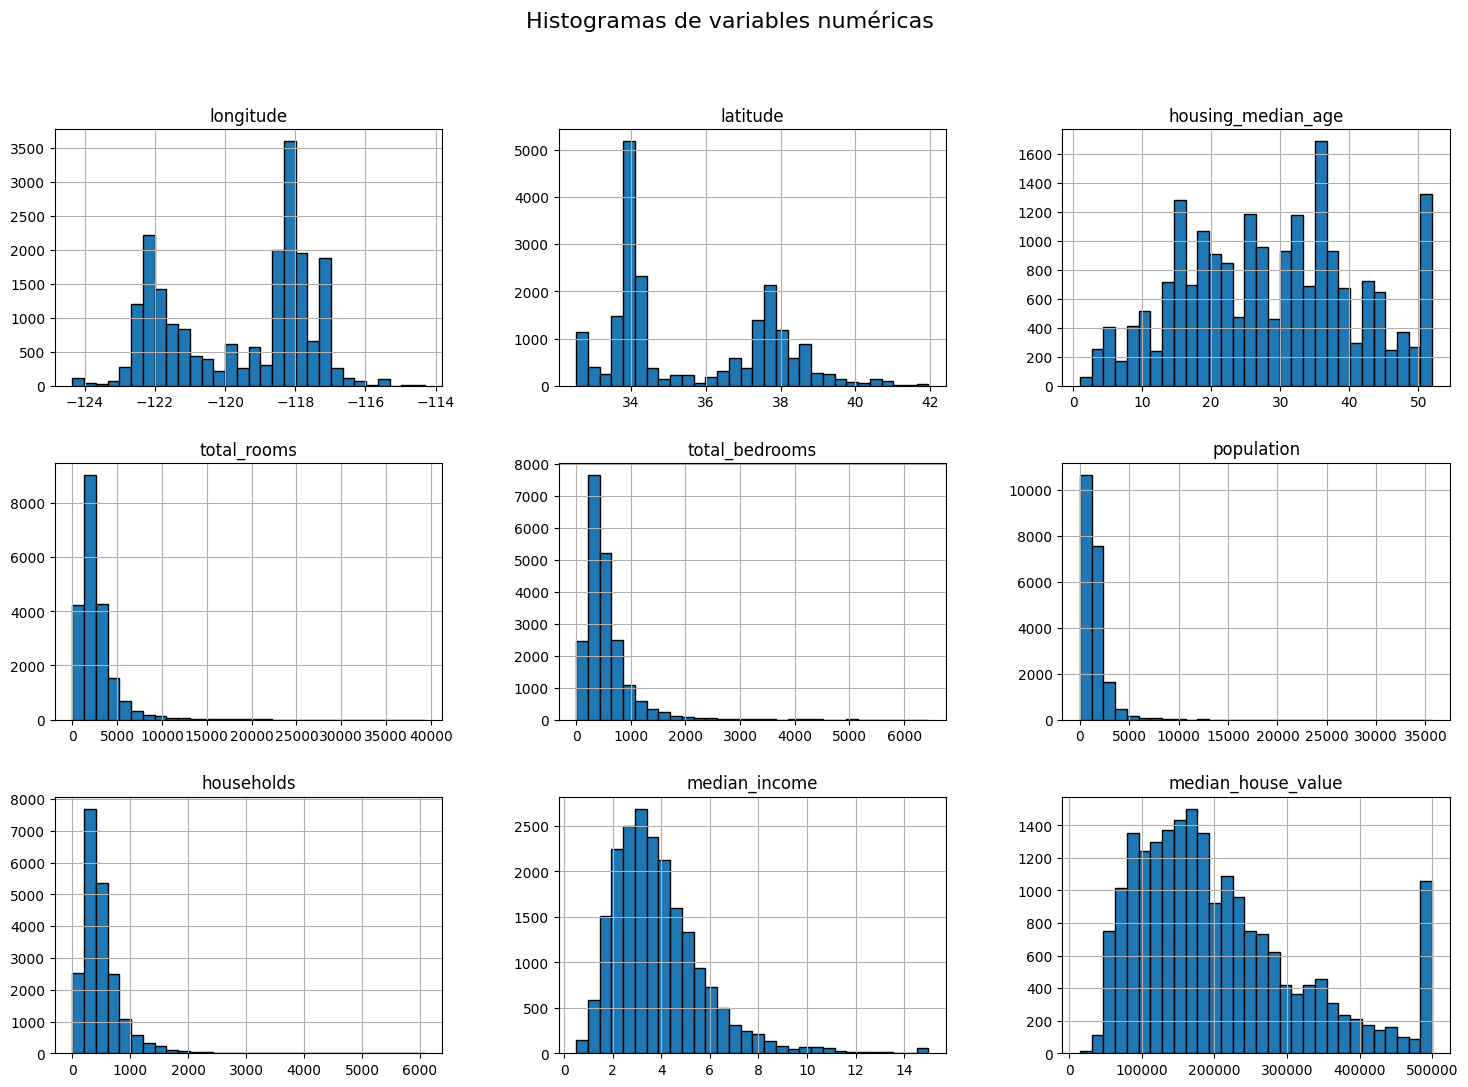

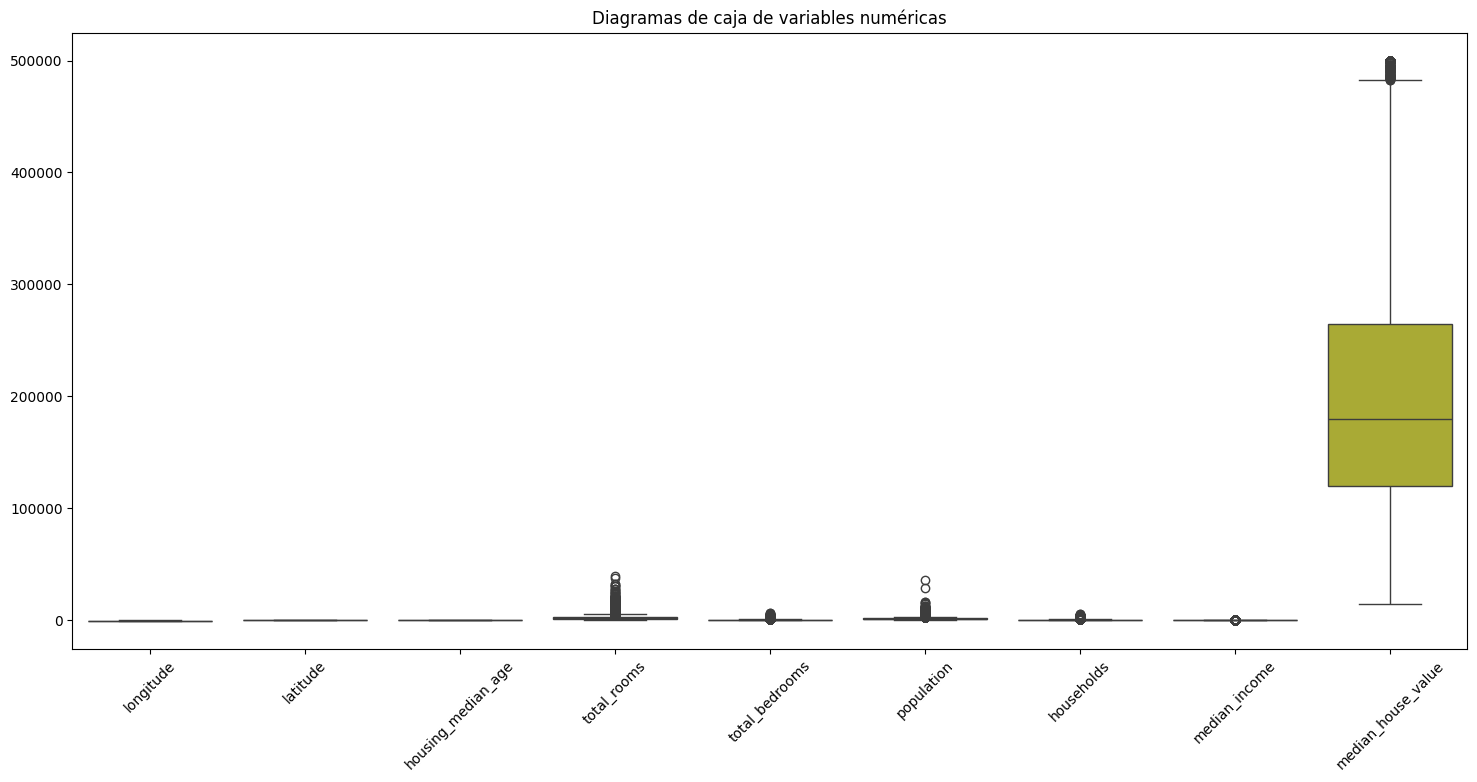

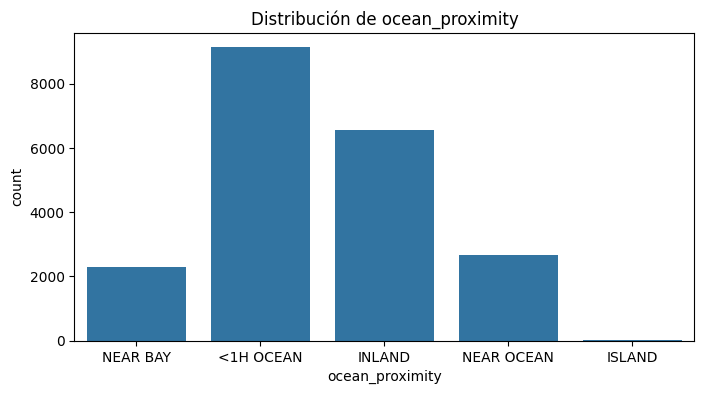

In [5]:
# Histogramas de todas las variables numéricas
df.hist(bins=30, figsize=(18, 12), edgecolor='black')
plt.suptitle('Histogramas de variables numéricas', fontsize=16)
plt.show()

# Diagramas de caja para identificar outliers
plt.figure(figsize=(18, 8))
sns.boxplot(data=df.select_dtypes(include=[np.number]))
plt.title('Diagramas de caja de variables numéricas')
plt.xticks(rotation=45)
plt.show()

# Gráfico de barras para la variable categórica principal
if 'ocean_proximity' in df.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x='ocean_proximity', data=df)
    plt.title('Distribución de ocean_proximity')
    plt.show()

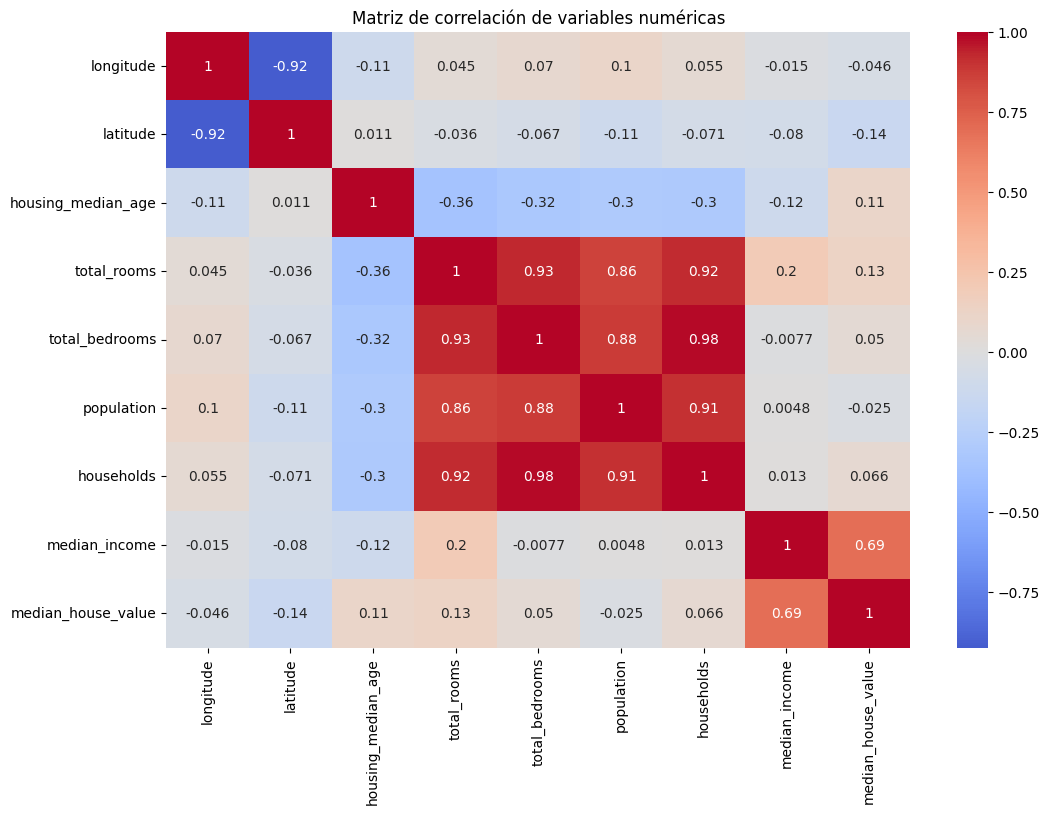

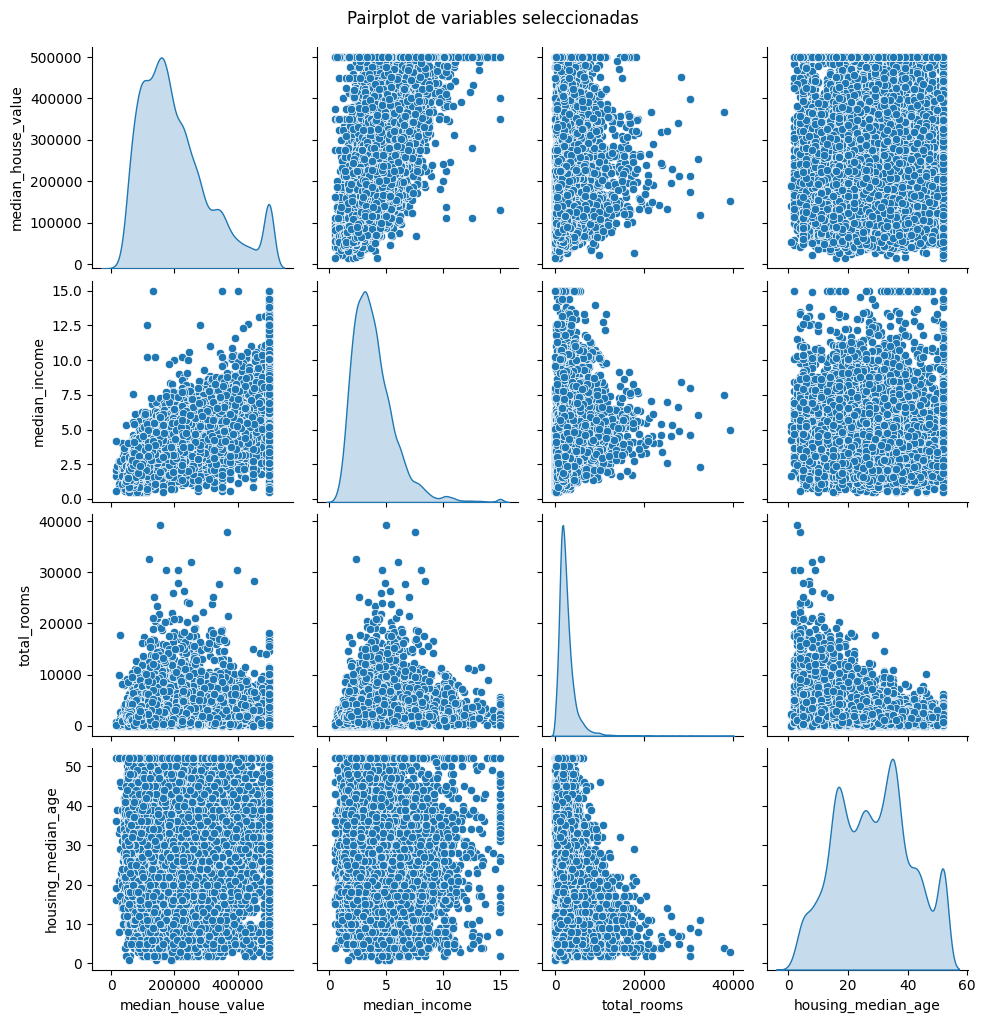

In [6]:
# Matriz de correlación y mapa de calor
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlación de variables numéricas')
plt.show()

# Pairplot de variables seleccionadas
cols = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
sns.pairplot(df[cols], diag_kind='kde')
plt.suptitle('Pairplot de variables seleccionadas', y=1.02)
plt.show()

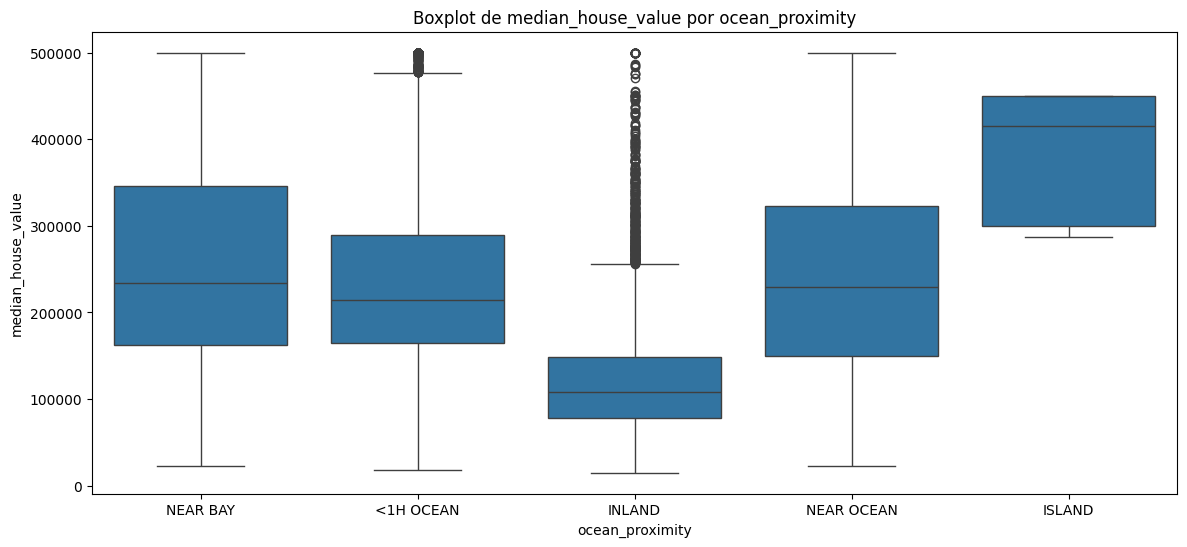

In [7]:
# Boxplot de median_house_value por ocean_proximity
if 'ocean_proximity' in df.columns:
    plt.figure(figsize=(14, 6))
    sns.boxplot(x='ocean_proximity', y='median_house_value', data=df, showfliers=True)
    plt.title('Boxplot de median_house_value por ocean_proximity')
    plt.show()

## 6. Transformación y creación de nuevas variables

En esta sección se generan variables derivadas y se transforman variables existentes para enriquecer el análisis y mejorar la capacidad predictiva del dataset.

In [8]:
# Creación de variables derivadas
# Densidad de habitaciones por hogar
if 'total_rooms' in df.columns and 'households' in df.columns:
    df['rooms_per_household'] = df['total_rooms'] / df['households']
# Proporción de dormitorios por habitación
if 'total_bedrooms' in df.columns and 'total_rooms' in df.columns:
    df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
# Personas por hogar
if 'population' in df.columns and 'households' in df.columns:
    df['population_per_household'] = df['population'] / df['households']

# Mostrar las primeras filas con las nuevas variables
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


## 7. Análisis estadístico descriptivo

Se calculan medidas estadísticas clave para las variables principales, incluyendo media, mediana, moda, desviación estándar y percentiles. Esto permite entender la tendencia central y dispersión de los datos.

In [9]:
# Medidas estadísticas descriptivas de variables seleccionadas
variables = ["housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income", "median_house_value", "rooms_per_household", "bedrooms_per_room", "population_per_household"]

for var in variables:
    if var in df.columns:
        print(f"\n--- {var} ---")
        print(f"Media: {df[var].mean():.2f}")
        print(f"Mediana: {df[var].median():.2f}")
        print(f"Moda: {df[var].mode()[0]:.2f}")
        print(f"Desviación estándar: {df[var].std():.2f}")
        print(f"Percentiles (25, 50, 75): {np.percentile(df[var].dropna(), [25, 50, 75])}")


--- housing_median_age ---
Media: 28.64
Mediana: 29.00
Moda: 52.00
Desviación estándar: 12.59
Percentiles (25, 50, 75): [18. 29. 37.]

--- total_rooms ---
Media: 2635.76
Mediana: 2127.00
Moda: 1527.00
Desviación estándar: 2181.62
Percentiles (25, 50, 75): [1447.75 2127.   3148.  ]

--- total_bedrooms ---
Media: 537.87
Mediana: 435.00
Moda: 280.00
Desviación estándar: 421.39
Percentiles (25, 50, 75): [296. 435. 647.]

--- population ---
Media: 1425.48
Mediana: 1166.00
Moda: 891.00
Desviación estándar: 1132.46
Percentiles (25, 50, 75): [ 787. 1166. 1725.]

--- households ---
Media: 499.54
Mediana: 409.00
Moda: 306.00
Desviación estándar: 382.33
Percentiles (25, 50, 75): [280. 409. 605.]

--- median_income ---
Media: 3.87
Mediana: 3.53
Moda: 3.12
Desviación estándar: 1.90
Percentiles (25, 50, 75): [2.5634  3.5348  4.74325]

--- median_house_value ---
Media: 206855.82
Mediana: 179700.00
Moda: 500001.00
Desviación estándar: 115395.62
Percentiles (25, 50, 75): [119600. 179700. 264725.]

---

## 8. Detección y tratamiento de valores atípicos

Se identifican outliers mediante métodos visuales y estadísticos, y se discuten estrategias para su tratamiento (eliminación, imputación, etc.).

In [10]:
# Detección de outliers usando el rango intercuartílico (IQR)
outlier_report = {}
for var in variables:
    if var in df.columns:
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[var] < lower) | (df[var] > upper)][var]
        outlier_report[var] = len(outliers)
        print(f"{var}: {len(outliers)} outliers detectados")

# Opcional: eliminar outliers extremos para modelado (ejemplo con median_house_value)
# df = df[(df['median_house_value'] >= lower) & (df['median_house_value'] <= upper)]

housing_median_age: 0 outliers detectados
total_rooms: 1287 outliers detectados
total_bedrooms: 1271 outliers detectados
population: 1196 outliers detectados
households: 1220 outliers detectados
median_income: 681 outliers detectados
median_house_value: 1071 outliers detectados
rooms_per_household: 511 outliers detectados
bedrooms_per_room: 582 outliers detectados
population_per_household: 711 outliers detectados


## 9. Preparación de datos para modelado

Se seleccionan variables relevantes, se dividen los datos en conjuntos de entrenamiento y prueba, y se aplican técnicas de escalado y codificación para preparar el dataset para el modelado predictivo.

In [11]:
# División estratificada según income_cat para evitar sesgo en la variable de ingreso
# Crear variable categórica para estratificación
if 'median_income' in df.columns:
    df['income_cat'] = pd.cut(df['median_income'],
                             bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                             labels=[1, 2, 3, 4, 5])
    split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    for train_idx, test_idx in split.split(df, df['income_cat']):
        train_set = df.loc[train_idx].copy()
        test_set = df.loc[test_idx].copy()
    # Eliminar income_cat de los sets finales
    for s in [train_set, test_set]:
        s.drop('income_cat', axis=1, inplace=True)
else:
    train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

print(f"Tamaño del set de entrenamiento: {train_set.shape}")
print(f"Tamaño del set de prueba: {test_set.shape}")

Tamaño del set de entrenamiento: (16512, 13)
Tamaño del set de prueba: (4128, 13)


In [12]:
# Imputación de valores faltantes en variables numéricas
num_cols = train_set.select_dtypes(include=[np.number]).columns.tolist()
imp_mean = SimpleImputer(strategy='mean')
train_set[num_cols] = imp_mean.fit_transform(train_set[num_cols])
test_set[num_cols] = imp_mean.transform(test_set[num_cols])

# Codificación one-hot de variables categóricas
def one_hot_encode(df, cat_col):
    encoder = OneHotEncoder(sparse_output=False)
    encoded = encoder.fit_transform(df[[cat_col]])
    encoded_df = pd.DataFrame(encoded, columns=encoder.categories_[0], index=df.index)
    return df.drop(cat_col, axis=1).join(encoded_df)

if 'ocean_proximity' in train_set.columns:
    train_set = one_hot_encode(train_set, 'ocean_proximity')
    test_set = one_hot_encode(test_set, 'ocean_proximity')

# Escalado de variables numéricas
scaler = MinMaxScaler()
train_set[num_cols] = scaler.fit_transform(train_set[num_cols])
test_set[num_cols] = scaler.transform(test_set[num_cols])

## 10. Exportación de datos procesados

Se guardan los conjuntos de datos de entrenamiento y prueba, ya limpios y preparados, para su uso posterior en modelado y análisis avanzado.

In [ ]:
# Guardar los datasets procesados para uso futuro
train_set.to_csv('housing_train_processed.csv', index=False)
test_set.to_csv('housing_test_processed.csv', index=False)
print("Datasets de entrenamiento y prueba exportados correctamente.")